<a href="https://colab.research.google.com/github/Yash-Yelave/LLM/blob/main/LLM_TA3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
!pip install -q -U groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.6 MB/s eta 0:00:00


🍳 Welcome to the AI Recipe Generator (Powered by Groq)!
-----------------------------------------------------------------

Step 1: Upload an image of your ingredients or food...


Saving Screenshot 2026-04-20 203429.png to Screenshot 2026-04-20 203429 (16).png

Here is the image you uploaded:


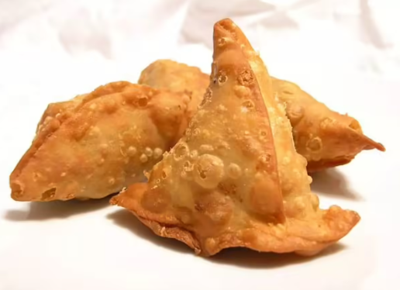

-----------------------------------------------------------------

Step 2: What other ingredients do you have? (e.g., salt, olive oil, 2 eggs)
Ingredients: potatoes, onions, peas, lentils, spices, chili peppers, mince, cheese

Generating your recipe... Please wait.

-----------------------------------------------------------------

**Creative Name:** Spicy Lentil Samosas

**Complete List of Ingredients:**

* Pastry dough (as seen in the image)
* Potatoes
* Onions
* Peas
* Lentils
* Spices
* Chili peppers
* Mince
* Cheese

**Step-by-Step Cooking Instructions:**

### Preparation

1. **Prepare the filling:**
	* Boil the lentils until they're tender. Drain and set aside.
	* Boil the diced potatoes until they're partially cooked. Drain and set aside.
	* Finely chop the onions and chili peppers.
	* Heat oil in a pan over medium heat. Add the chopped onions and chili peppers. Sauté until the onions are translucent.
	* Add the minced meat to the pan, breaking it up with a spoon as it cooks. Co

In [56]:
import base64
import PIL.Image
from IPython.display import display  # <-- We import the display tool here
from groq import Groq
from google.colab import userdata
from google.colab import files

# Helper function to convert the image to Base64 so Groq can read it
def encode_image_to_base64(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

def generate_recipe_with_groq():
    # 1. Authenticate with your Groq Secret
    try:
        api_key = userdata.get('GROQ_API_KEY')
        client = Groq(api_key=api_key)
    except Exception as e:
        print("Error: Could not find 'GROQ_API_KEY' in Colab Secrets.")
        return

    print("🍳 Welcome to the AI Recipe Generator (Powered by Groq)!")
    print("-" * 65)

    print("\nStep 1: Upload an image of your ingredients or food...")
    uploaded = files.upload()

    if not uploaded:
        print("No image uploaded. Exiting.")
        return

    filename = list(uploaded.keys())[0]

    # --- NEW FEATURE: DISPLAY THE IMAGE ---
    print("\nHere is the image you uploaded:")
    img = PIL.Image.open(filename)
    img.thumbnail((400, 400)) # Resizes the preview so it fits nicely on screen
    display(img)              # Renders the image in the Colab output!
    print("-" * 65)
    # --------------------------------------

    # 2. Encode the image for the API
    base64_image = encode_image_to_base64(filename)

    print("\nStep 2: What other ingredients do you have? (e.g., salt, olive oil, 2 eggs)")
    extra_ingredients = input("Ingredients: ")

    print("\nGenerating your recipe... Please wait.\n")
    print("-" * 65)

    prompt = f"""
    You are an expert chef. Look at the attached image and the additional ingredients provided below.

    Additional Ingredients: {extra_ingredients}

    Please provide:
    1. A creative name for the dish.
    2. A complete list of ingredients (combining what you see in the image and the text list).
    3. Step-by-step cooking instructions.

    Format the output clearly.
    """

    try:
        # 3. Call the updated Llama 4 Vision model
        completion = client.chat.completions.create(
            model="meta-llama/llama-4-scout-17b-16e-instruct",
            messages=[
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "text",
                            "text": prompt
                        },
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": f"data:image/jpeg;base64,{base64_image}"
                            }
                        }
                    ]
                }
            ],
            temperature=0.7,
            max_tokens=1024
        )

        # Print the final generated recipe
        print("\n" + completion.choices[0].message.content)

    except Exception as e:
        print(f"\n❌ API Error Details: {e}")

# 4. Run the application
generate_recipe_with_groq()